# Amphibian Threat Patterns: Geographic & Taxonomic Analysis
**DSCI 235 — Final Project | Emerson Tomlinson**

---



In [400]:
from IPython.display import Image, display
display(Image(url="https://raw.githubusercontent.com/emersontomlinson/dsci235-final-project/main/salamander.jpg", width=280))

---

## Introduction

Amphibians are the most threatened class of vertebrates on Earth. This project conducts an 
exploratory analysis of global amphibian extinction risk patterns using the IUCN Global 
Amphibian Assessment 2 (GAA2) dataset, published in Luedtke et al. (2023) in *Nature*. 
The dataset covers 8,011 species assessed for the IUCN Red List and includes taxonomic 
information, Red List categories, biogeographic realm occurrence, and breeding strategy data.

**Data source:** Luedtke, J.A. et al. (2023). Ongoing declines for the world's amphibians 
in the face of emerging threats. *Nature*, 622, 308–314.  
https://doi.org/10.1038/s41586-023-06578-4

Project github link: https://github.com/emersontomlinson/dsci235-final-project.git

---

## Research Questions

**Regional Threat Hotspots:** Which biogeographic realms have the highest 
concentration of Critically Endangered amphibian species?

**Taxonomic Vulnerability by Region:** Which order (Anura, Caudata, Gymnophiona) 
is most threatened overall, and does that pattern vary across biogeographic realms?

**Data Deficiency as Hidden Risk:** Are there realms where a disproportionately 
large share of amphibian species are Data Deficient, suggesting the true scale of the 
crisis may be underestimated?

---

In [401]:
# Amphibian Threat Patterns: Geographic & Taxonomic Analysis
# DSCI 235 Final Project
# Data: IUCN Global Amphibian Assessment 2 (Luedtke et al. 2023)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/emersontomlinson/dsci235-final-project/main/All_amphibians_tabular_data.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")

Dataset loaded successfully!
Shape: (8011, 25)

Columns:
['Order', 'Family', 'Species Name', '1980 GAA2 Red List Category', '2004 GAA2 Red List Category', '1980-2004 Genuine Change?', '1980-2004 Primary Driver', 'Grouped 1980-2004 Primary Driver', '1980-2004 Genuine downlisting due to conservation', '2022 GAA2 Red List Category', '2022 Red List Criteria', '2004-2022 Genuine Change?', ' 2004-2022 Primary Driver', 'Grouped 2004-2022 Primary Driver', '2004-2022 Genuine downlisting due to conservation', 'Afrotropical', 'Australasian/Oceanian', 'Indomalayan', 'Nearctic', 'Neotropical', 'Palearctic', 'Egg Laying', 'Free Living Larval Stage', 'Live Birth ', 'Water Breeding']


In [402]:
# explore data
print("=== First 5 rows ===")
print(df.head())

print("\n=== Data types ===")
print(df.dtypes)

print("\n=== Missing values ===")
print(df.isnull().sum())

print("\n=== Unique Red List Categories (2022) ===")
print(df['2022 GAA2 Red List Category'].value_counts())

print("\n=== Orders ===")
print(df['Order'].value_counts())

=== First 5 rows ===
   Order        Family           Species Name 1980 GAA2 Red List Category  \
0  ANURA       RANIDAE     Abavorana luctuosa                          LC   
1  ANURA       RANIDAE       Abavorana nazgul                          CR   
2  ANURA  HYPEROLIIDAE    Acanthixalus sonjae                          VU   
3  ANURA  HYPEROLIIDAE  Acanthixalus spinosus                          LC   
4  ANURA       HYLIDAE       Acris blanchardi                          LC   

  2004 GAA2 Red List Category 1980-2004 Genuine Change?  \
0                          LC                        No   
1                          CR                        No   
2                          VU                        No   
3                          LC                        No   
4                          LC                        No   

  1980-2004 Primary Driver Grouped 1980-2004 Primary Driver  \
0                      NaN                              NaN   
1                      NaN         

In [403]:
# clean up
df.columns = df.columns.str.strip()

realm_cols = ['Afrotropical', 'Australasian/Oceanian', 'Indomalayan', 
              'Nearctic', 'Neotropical', 'Palearctic']
df[realm_cols] = df[realm_cols].fillna(0)

df = df.rename(columns={'2022 GAA2 Red List Category': 'RedList_2022'})

threat_map = {
    'EX': 'Extinct',
    'EW': 'Extinct in Wild',
    'CR(PEW)': 'Critically Endangered',
    'CR(PE)': 'Critically Endangered',
    'CR': 'Critically Endangered',
    'EN': 'Endangered',
    'VU': 'Vulnerable',
    'NT': 'Near Threatened',
    'LC': 'Least Concern',
    'DD': 'Data Deficient'
}
df['Threat_Tier'] = df['RedList_2022'].map(threat_map)

df['is_threatened'] = df['RedList_2022'].isin(['CR', 'CR(PE)', 'CR(PEW)', 'EN', 'VU'])

df['is_DD'] = df['RedList_2022'] == 'DD'

print(f"\nThreat tier counts:\n{df['Threat_Tier'].value_counts()}")
print(f"\nThreatened species: {df['is_threatened'].sum()}")
print(f"Data Deficient species: {df['is_DD'].sum()}")


Threat tier counts:
Least Concern            3739
Endangered               1264
Data Deficient            909
Vulnerable                811
Critically Endangered     798
Near Threatened           451
Extinct                    37
Extinct in Wild             2
Name: Threat_Tier, dtype: int64

Threatened species: 2873
Data Deficient species: 909


In [404]:
# Q1: Regional Threat Hotspots 

realm_dfs = []
for realm in realm_cols:
    temp = df[df[realm] == 1].copy()
    temp['Realm'] = realm
    realm_dfs.append(temp)

df_realms = pd.concat(realm_dfs)

print(f"Total species-realm records: {len(df_realms)}")
print(f"\nSpecies count per realm:")
print(df_realms.groupby('Realm')['Species Name'].count().sort_values(ascending=False))

Total species-realm records: 8276

Species count per realm:
Realm
Neotropical              3852
Indomalayan              1526
Afrotropical             1170
Australasian/Oceanian     760
Palearctic                556
Nearctic                  412
Name: Species Name, dtype: int64


In [405]:
# calculate % of species in each realm that are critically endangered
cr_counts = df_realms[df_realms['RedList_2022'].isin(['CR', 'CR(PE)', 'CR(PEW)'])]\
    .groupby('Realm')['Species Name'].count()

total_counts = df_realms.groupby('Realm')['Species Name'].count()

cr_pct = (cr_counts / total_counts * 100).round(1).sort_values(ascending=False)

print("% of species that are Critically Endangered by realm:")
print(cr_pct)

% of species that are Critically Endangered by realm:
Realm
Neotropical              14.8
Afrotropical              7.6
Nearctic                  5.1
Palearctic                5.0
Indomalayan               4.4
Australasian/Oceanian     3.4
Name: Species Name, dtype: float64


In [406]:
from IPython.display import Image, display
display(Image(url="https://raw.githubusercontent.com/emersontomlinson/dsci235-final-project/main/frog.jpg", width=280))

## Q1: Regional Threat Hotspots

The Neotropical realm (Central and South America, Caribbean) is by far the most 
critical hotspot for amphibian extinction risk. It contains 571 Critically Endangered 
species, more than all other realms combined, and 14.8% of its amphibian species 
are critically endangered, nearly double the next highest realm (Afrotropical at 7.6%). 


The Australasian/Oceanian realm has the lowest proportion of CR species at 3.4%, 
likely partly due to New Guinea currently being largely free of the chytrid fungus.

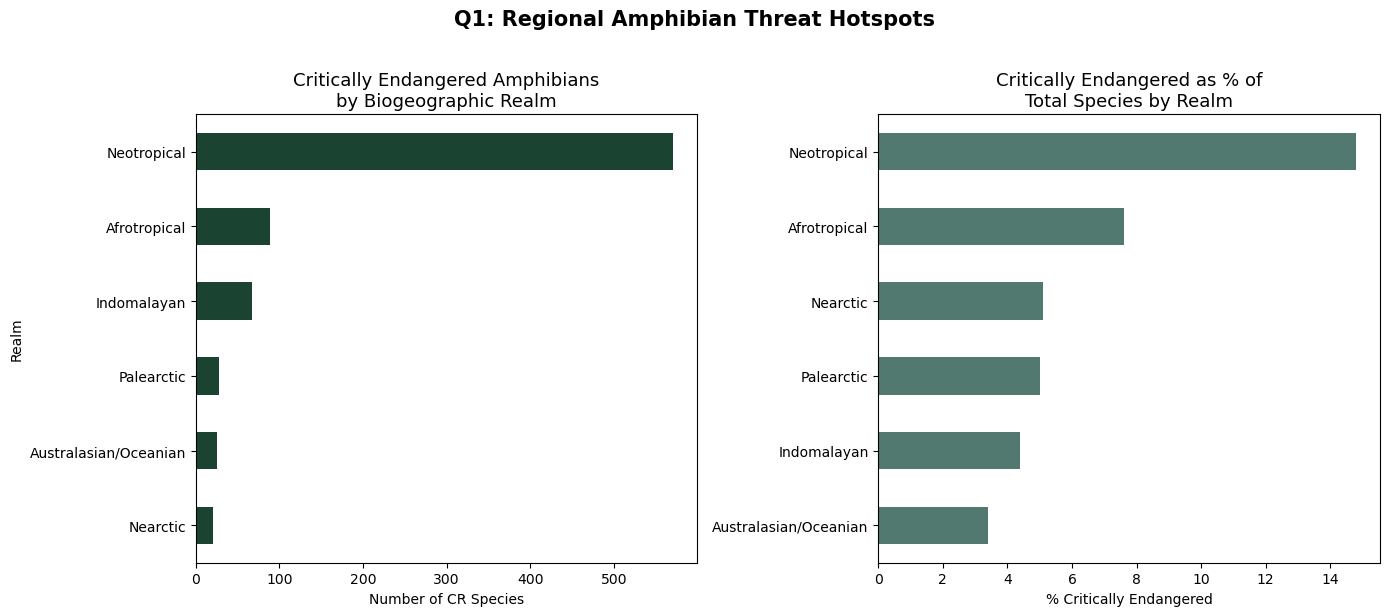

In [407]:
#  Q1 Visualization

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# plot 1: raw count of CR species by realm
cr_counts.sort_values().plot(kind='barh', ax=ax1, color='#1B4332')
ax1.set_title('Critically Endangered Amphibians\nby Biogeographic Realm', fontsize=13)
ax1.set_xlabel('Number of CR Species')
ax1.set_ylabel('Realm')

# plot 2: % of species that are CR by realm
cr_pct.sort_values().plot(kind='barh', ax=ax2, color='#52796F')
ax2.set_title('Critically Endangered as % of\nTotal Species by Realm', fontsize=13)
ax2.set_xlabel('% Critically Endangered')
ax2.set_ylabel('')

plt.suptitle('Q1: Regional Amphibian Threat Hotspots', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q1_regional_hotspots.png', dpi=150, bbox_inches='tight')
plt.show()


In [408]:
from IPython.display import Image, display
display(Image(url="https://raw.githubusercontent.com/emersontomlinson/dsci235-final-project/main/hellbender.jpg", width=280))

## Q2: Taxonomic Vulnerability by Region

Which amphibian order is most threatened overall - and does that pattern hold across 
all biogeographic realms, or are certain groups only struggling in specific parts of the world?

In [409]:
# Q2: Taxonomic Vulnerability by Region 

# Overall threat rate by order
order_stats = df.groupby('Order').agg(
    total=('Species Name', 'count'),
    threatened=('is_threatened', 'sum'),
    CR=('RedList_2022', lambda x: x.isin(['CR', 'CR(PE)', 'CR(PEW)']).sum()),
    DD=('is_DD', 'sum')
).reset_index()

order_stats['pct_threatened'] = (order_stats['threatened'] / order_stats['total'] * 100).round(1)
order_stats['pct_CR'] = (order_stats['CR'] / order_stats['total'] * 100).round(1)
order_stats['pct_DD'] = (order_stats['DD'] / order_stats['total'] * 100).round(1)

print("=== Threat rates by Order (global) ===")
print(order_stats[['Order', 'total', 'threatened', 'pct_threatened', 'pct_CR', 'pct_DD']])

=== Threat rates by Order (global) ===
         Order  total  threatened  pct_threatened  pct_CR  pct_DD
0        ANURA   7047        2429            34.5     9.4    11.0
1      CAUDATA    758         425            56.1    17.4     5.9
2  GYMNOPHIONA    206          19             9.2     1.9    44.2


In [410]:
# threat rate by Order and Realm
order_realm = df_realms.groupby(['Realm', 'Order']).agg(
    total=('Species Name', 'count'),
    threatened=('is_threatened', 'sum')
).reset_index()

order_realm['pct_threatened'] = (order_realm['threatened'] / order_realm['total'] * 100).round(1)

# Pivot for easy reading
pivot = order_realm.pivot(index='Realm', columns='Order', values='pct_threatened')
print("=== % Threatened by Order and Realm ===")
print(pivot)

=== % Threatened by Order and Realm ===
Order                  ANURA  CAUDATA  GYMNOPHIONA
Realm                                             
Afrotropical            31.7      NaN         34.5
Australasian/Oceanian   10.8      NaN          NaN
Indomalayan             32.2     60.0          5.3
Nearctic                18.7     29.9          NaN
Neotropical             42.2     72.2          4.9
Palearctic              19.3     62.0          0.0


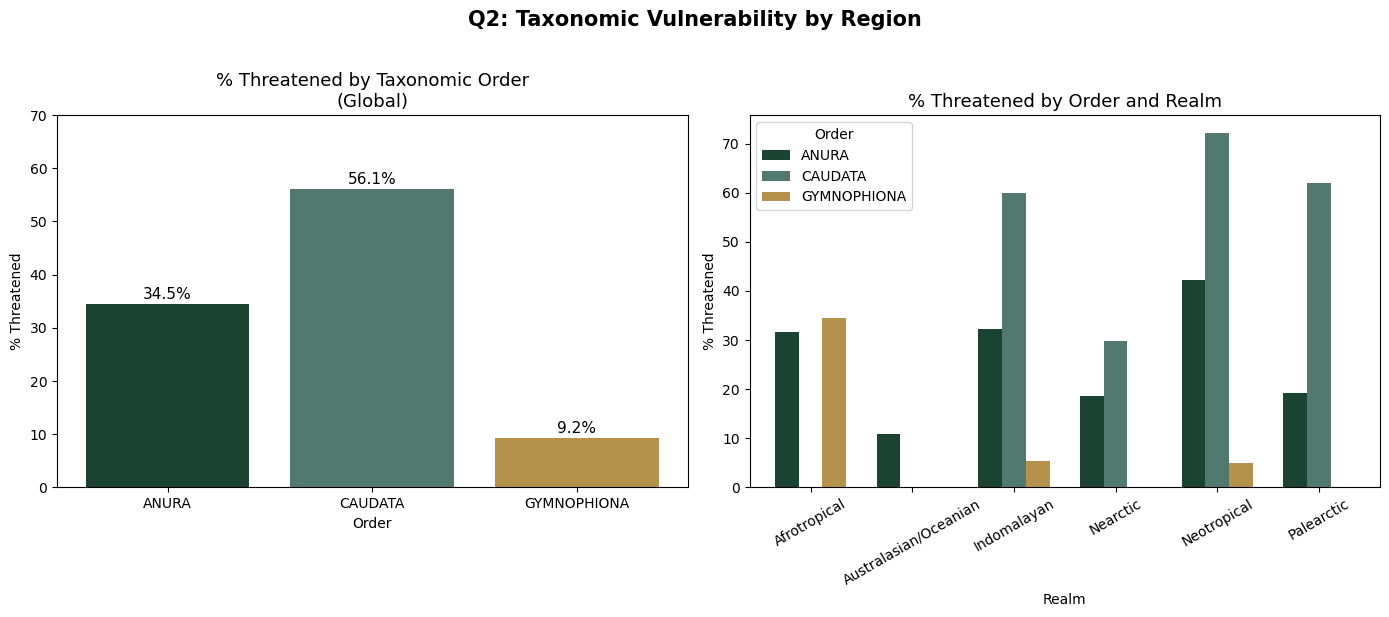

In [411]:
# Q2 Visualization 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: global threat rate by order
colors = ['#1B4332', '#52796F', '#B5924C']
ax1.bar(order_stats['Order'], order_stats['pct_threatened'], color=colors)
ax1.set_title('% Threatened by Taxonomic Order\n(Global)', fontsize=13)
ax1.set_xlabel('Order')
ax1.set_ylabel('% Threatened')
ax1.set_ylim(0, 70)
for i, row in order_stats.iterrows():
    ax1.text(i, row['pct_threatened'] + 1, f"{row['pct_threatened']}%", 
             ha='center', fontsize=11)

# Plot 2: heatmap style grouped bar chart by realm and order
pivot_clean = pivot.dropna(how='all')
pivot_clean.plot(kind='bar', ax=ax2, color=colors, width=0.7)
ax2.set_title('% Threatened by Order and Realm', fontsize=13)
ax2.set_xlabel('Realm')
ax2.set_ylabel('% Threatened')
ax2.legend(title='Order')
ax2.tick_params(axis='x', rotation=30)

plt.suptitle('Q2: Taxonomic Vulnerability by Region', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q2_taxonomic_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()


### Q2 Findings

Caudata (salamanders and newts) are the most threatened amphibian order globally, 
with 56.1% of species threatened, significantly higher than Anura (frogs) at 34.5%. 
This pattern is consistent across almost every biogeographic realm, but is most extreme 
in the Neotropics where 72.2% of salamander species are threatened, followed by the 
Palearctic (62.0%) and Indomalayan (60.0%) realms.

Gymnophiona (caecilians) appear safe at only 9.2% threatened globally, 
but this is likely only a reflection of how poorly studied they are. 44.2% of caecilian 
species are classified as data deficient, the highest of any order. This leads to a question we'll address in Q3.

Australasian/Oceanian frogs have the lowest threat rate of any order-realm 
combination at 10.8%, consistent with New Guinea currently being largely free of the 
chytrid fungus Bd.

In [412]:
from IPython.display import Image, display
display(Image(url="https://raw.githubusercontent.com/emersontomlinson/dsci235-final-project/main/caecilians.JPG", width=280))

## Q3: Data Deficiency as Hidden Risk

A species classified as Data Deficient (DD) can seem safe on a surface level, however, it often just means we 
don't have enough information to assess it. Research suggests the majority of DD amphibians are likely threatened. Are there realms where DD species are 
disproportionately concentrated, suggesting we may be underestimating the crisis there?

In [413]:
# Q3: Data Deficiency as Hidden Risk

# DD rate by realm
dd_by_realm = df_realms.groupby('Realm').agg(
    total=('Species Name', 'count'),
    dd_count=('is_DD', 'sum')
).reset_index()

dd_by_realm['pct_DD'] = (dd_by_realm['dd_count'] / dd_by_realm['total'] * 100).round(1)
dd_by_realm = dd_by_realm.sort_values('pct_DD', ascending=False)

print("=== Data Deficient % by Realm ===")
print(dd_by_realm[['Realm', 'total', 'dd_count', 'pct_DD']])

# DD rate by order
print("\n=== Data Deficient % by Order ===")
print(order_stats[['Order', 'total', 'pct_DD']])

=== Data Deficient % by Realm ===
                   Realm  total  dd_count  pct_DD
1  Australasian/Oceanian    760       133    17.5
2            Indomalayan   1526       231    15.1
0           Afrotropical   1170       158    13.5
4            Neotropical   3852       341     8.9
5             Palearctic    556        37     6.7
3               Nearctic    412        13     3.2

=== Data Deficient % by Order ===
         Order  total  pct_DD
0        ANURA   7047    11.0
1      CAUDATA    758     5.9
2  GYMNOPHIONA    206    44.2


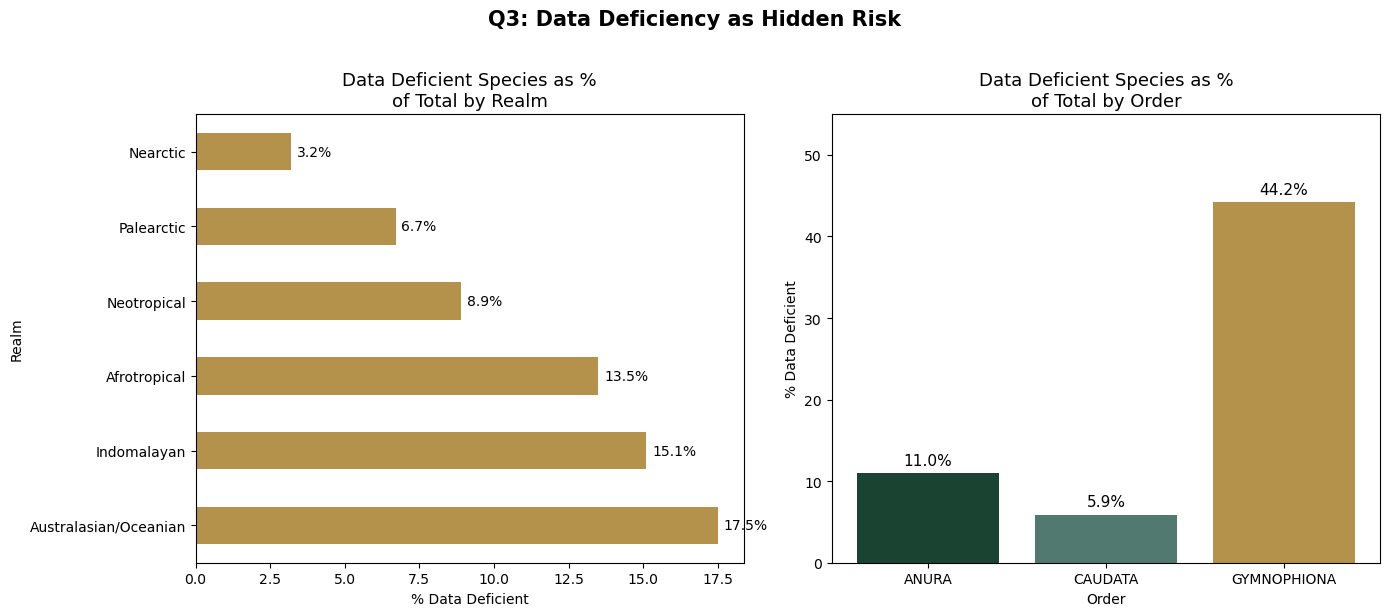

In [414]:
#  Q3 Visualization

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: DD % by realm
dd_by_realm.plot(kind='barh', x='Realm', y='pct_DD', ax=ax1, 
                 color='#B5924C', legend=False)
ax1.set_title('Data Deficient Species as %\nof Total by Realm', fontsize=13)
ax1.set_xlabel('% Data Deficient')
ax1.set_ylabel('Realm')
for i, row in dd_by_realm.reset_index().iterrows():
    ax1.text(row['pct_DD'] + 0.2, i, f"{row['pct_DD']}%", va='center', fontsize=10)

# Plot 2: DD % by order
ax2.bar(order_stats['Order'], order_stats['pct_DD'], 
        color=['#1B4332', '#52796F', '#B5924C'])
ax2.set_title('Data Deficient Species as %\nof Total by Order', fontsize=13)
ax2.set_xlabel('Order')
ax2.set_ylabel('% Data Deficient')
ax2.set_ylim(0, 55)
for i, row in order_stats.iterrows():
    ax2.text(i, row['pct_DD'] + 1, f"{row['pct_DD']}%", 
             ha='center', fontsize=11)

plt.suptitle('Q3: Data Deficiency as Hidden Risk', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q3_data_deficiency.png', dpi=150, bbox_inches='tight')
plt.show()


### Q3 Findings

Data Deficiency is not evenly distributed. Instead, it is concentrated in the least-studied 
regions and taxonomic groups, suggesting the true scale of the amphibian crisis is 
likely underestimated.

By realm, Australasian/Oceanian (17.5%) and Indomalayan (15.1%) have the highest 
proportions of Data Deficient species - both biodiversity-rich tropical regions where 
many species remain poorly studied. By contrast, the Nearctic (North America) has 
only 3.2% DD species, reflecting the relatively well-funded research infrastructure 
in that region.

The most stand-out finding is taxonomic: 44.2% of all Gymnophiona (caecilian) species 
are Data Deficient — nearly half the entire order. This means the apparently low 
threat rate for caecilians seen in Q2 (9.2%) - almost certainly - underestimates their true 
extinction risk. Caecilians are burrowing, hard to find animals that are extremely difficult 
to survey, and they represent a major blind spot in global amphibian conservation.

## Conclusions

This exploratory analysis of 8,011 amphibian species from the IUCN Global Amphibian 
Assessment 2 reveals three clear patterns in global amphibian extinction risk:

**1. The Neotropics is the world's most critical amphibian hotspot.** With 571 
critically endangered species and 14.8% of its amphibian fauna at CR status, Central 
and South America have a disproportionate amount of the global amphibian crisis, with
almost double the rate of the next most threatened realm.

**2. Salamanders are the most threatened amphibian order globally.** With 56.1% of 
species threatened, Caudata far passes Anura (34.5%) and this pattern holds up across 
almost every biogeographic realm. The situation is most severe in the Neotropics 
where 72.2% of salamander species are threatened.

**3. Data Deficiency hides the true scale of the crisis, particularly for caecilians 
and tropical regions.** (44.2%) of all caecilian species are data 
deficient, meaning their apparently low threat rate is almost surely an 
underestimate. Australasian/Oceanian and Indomalayan realms also have high DD rates, 
suggesting significant undocumented extinction risk in these biodiversity-rich regions.

Together these findings highlight that amphibian conservation resources should be 
prioritized toward the Neotropics and salamander-rich regions, while substantially 
more research funding is needed for caecilians and understudied tropical regions 
before species disappear before we even know they were at risk.